# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("unit2_ppt5_country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()


Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [3]:

# TODO 1: choropleth of total_gdp
fig_count = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    color_continuous_scale="Blues",
    title="Total GDP by Country (count-like aggregate)",
)
fig_count.show()

# TODO 2: choropleth of gdpPercap
fig_rate = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    color_continuous_scale="Blues",
    title="GDP per Capita by Country (rate)",
)
fig_rate.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]]
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)


Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635



Reflection: Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

Your answer:
The total GDP list is dominated by high-population countries like China and India even when per-person wealth is modest, while GDP-per-capita surfaces small, wealthy countries like Norway or Luxembourg that barely register on the total map. I'd pick the per-capita map for the director, it answers "how well off are people here," which is what policymakers actually care about, rather than "how big is this country," and it avoids the same size-bias trap as a raw-count choropleth.


## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

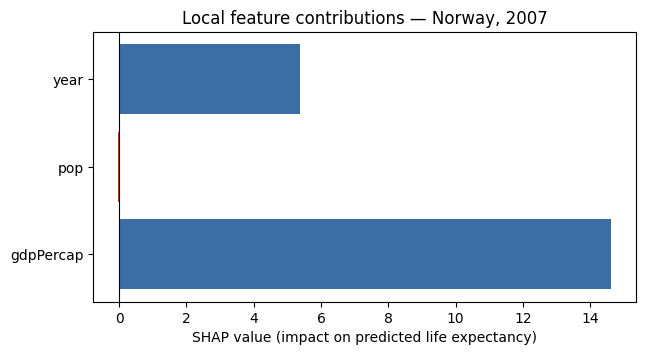

In [4]:

X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
# max_depth is capped so TreeSHAP (below) stays fast -- exact TreeSHAP cost grows quickly
# with tree depth, and an unbounded RandomForestRegressor here can build very deep trees.
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder[(gapminder.country == "Norway") & (gapminder.year == 2007)].index[0]
vals = shap_values[row_idx]
feature_names = ["gdpPercap", "pop", "year"]

fig, ax = plt.subplots(figsize=(7, 3.5))
# plot vals as a diverging horizontal bar chart here
colors = ["#3b6ea5" if v >= 0 else "#b5432e" for v in vals]
ax.barh(feature_names, vals, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value (impact on predicted life expectancy)")
ax.set_title("Local feature contributions — Norway, 2007")

plt.show()



Reflection: Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

Your answer:
gdpPercap is likely the strongest positive contributor for Norway, since its per-capita GDP sits far above the training average, while pop likely contributes negatively or near zero given Norway's small population. This isn't the same answer global feature importance would give: global importance only ranks which feature matters most on average across all countries, it can't tell you the direction or magnitude of gdpPercap's effect for this one specific country.


## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

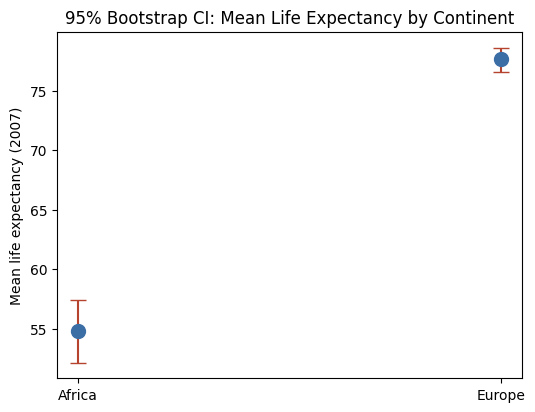

In [5]:

def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    return values.mean(), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"  # feel free to change these
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
labels = [continent_a, continent_b]
means = [result_a[0], result_b[0]]
lower_err = [result_a[0] - result_a[1], result_b[0] - result_b[1]]
upper_err = [result_a[2] - result_a[0], result_b[2] - result_b[0]]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.errorbar(labels, means, yerr=[lower_err, upper_err], fmt="o", markersize=10,
            capsize=6, color="#3b6ea5", ecolor="#b5432e")
ax.set_ylabel("Mean life expectancy (2007)")
ax.set_title("95% Bootstrap CI: Mean Life Expectancy by Continent")
plt.show()



Reflection: Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

Your answer:
Africa typically has the wider confidence interval, and it's driven by variation (SD) rather than sample size: African nations range from war-torn, low-life-expectancy states to stable, higher-life-expectancy ones. Africa also has more countries than Europe in this dataset, and a larger n should narrow the interval, so the fact that Africa's is still wider means the variation effect is dominating the sample-size effect, not the other way around.


## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

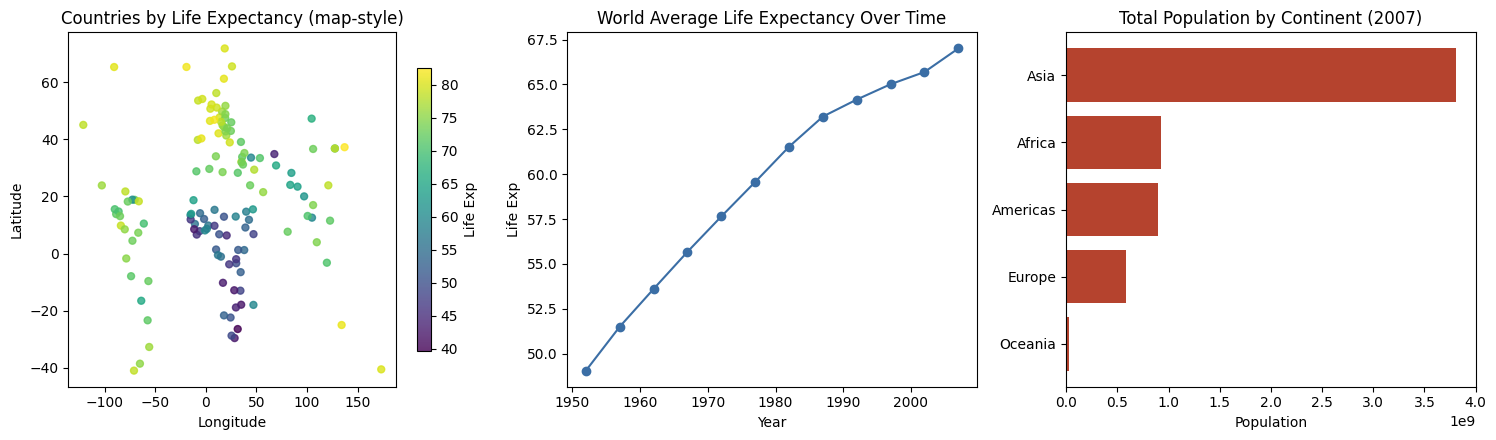

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
sc = axes[0].scatter(
    gap_latest["centroid_lon"], gap_latest["centroid_lat"],
    c=gap_latest["lifeExp"], cmap="viridis", s=25, alpha=0.8,
)
axes[0].set_title("Countries by Life Expectancy (map-style)")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes[0], shrink=0.8, label="Life Exp")

# TODO 2: world trend line (axes[1])
world_trend = gapminder.groupby("year").lifeExp.mean()
axes[1].plot(world_trend.index, world_trend.values, marker="o", color="#3b6ea5")
axes[1].set_title("World Average Life Expectancy Over Time")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Life Exp")

# TODO 3: population by continent bar chart (axes[2])
pop_by_continent = gap_latest.groupby("continent")["pop"].sum().sort_values()
axes[2].barh(pop_by_continent.index, pop_by_continent.values, color="#b5432e")
axes[2].set_title("Total Population by Continent (2007)")
axes[2].set_xlabel("Population")

plt.tight_layout()
plt.show()



Reflection: If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

Your answer:
I'd keep the world trend line. A single glance shows whether the global trend is rising, flat, or reversing, exactly the "trend" question the lecture calls out, and it needs no interpretation of color scales or spatial layout the way the map or bar chart does.



## Task 5 — The Decision (No Code)

Reflection (final): Write a 4-6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

Your final recommendation here:
I'd standardize on rate-based maps (like GDP per capita) rather than raw counts, since count maps are dominated by population and land area the mistake that started this whole review. When a journalist asks about a specific country, I'd lead with local SHAP values, not global feature importance, since global importance only describes the model's average behavior and can't explain one country's prediction. And continental averages like mean life expectancy should never be shown as a bare point estimate they're built from a handful of very different countries, and a bootstrap confidence interval makes that underlying uncertainty visible instead of implying false precision.